# 4. Climate scenarios

In this chapter, different climate scenarios are used to model the future discharge pattern of the Okavango River. First, the scenarios are elaborated. Using historic CMIP forcing data, the discharge is modelled using the HBV model and compared to the observed discharge. Lastly, the daily discharge is modelled for the period from 2030 to 2100 for the different climate scenarios.

## 4.1 SSP climate scenarios
For the future projection of the discharge pattern of the Okavango river four climate scenarios are used: SSP1-2.6, SSP2-4.5, SSP3-7.0 and SSP5-8.5.

In the SSP1-2.6 scenario, global CO2 emissions are reduced which results in a temperature rise of 1.8 °C by 2100. CO2 emissions will reach net-zero after 2050 in this scenario. The SSP2-4.5 scenario is the ‘middle-of-the-road’ scenario. Until 2050, CO2 emissions will remain similar to the current emissions and will not reach net-zero by 2100. This results in a projected temperature rise of 2.7 °C by the end of the century. In the SSP3-7.0 scenario, temperature rise will reach 3.6 °C as CO2 emissions double by 2100. The SSP5-8.5 scenario is the most extreme. In this scenario, CO2 emissions will double by 2050 which results in a temperature rise of 4.4 °C (Anthesis, 2025).  


## 4.2 Modelling historic discharge using CMIP6

In the code below, the historic CMIP forcing data is generated. 

In [1]:
#Loading packages
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

from scipy.stats import qmc
from scipy.interpolate import interp1d

In [2]:
#Loading shapefile of the catchment area of Mohembo
shapefile_path =  Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/Shapefile" / "CatchmentArea_4326.shp"

#Defining start and end date
experiment_start_date = "1970-01-01T00:00:00Z"
experiment_end_date = "2014-12-31T00:00:00Z"

#Creating path
forcing_path_CMIP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/CMIP"  
forcing_path_CMIP.mkdir(exist_ok=True)

cmip_historical =  {
   'project': 'CMIP6',
   'exp': 'historical',
   'dataset': 'MPI-ESM1-2-HR',
   "ensemble": 'r1i1p1f1',
   'grid': 'gn'
}

#Generating historic CMIP forcing data
#CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_historical,
#   start_time=experiment_start_date,
#   end_time=experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "historical",)

#Loading historic CMIP forcing data
historical_CMIP_location = forcing_path_CMIP / "historical" / "work" / "diagnostic" / "script"
historical_CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_CMIP_location)

In figure 4.1, the daily discharge of the Okavango River is modelled using the HBV model and CMIP forcing data in the period from 1975 to 2014. The HBV model shows some inaccuracies. For this reason, quantile mapping is used to correct the output of the model with CMIP forcing data. Quantile mapping is used to correct biases in projection models. This technique aligns the observed quantile distribution with the quantile distribution of the modelled output (Gutierrez, 2023). In figure 4.2, quantile mapping is used on the output of the model with historic CMIP forcing data. The code for the HBV model using the historic CMIP data and the quantile mapping results is shown below. 

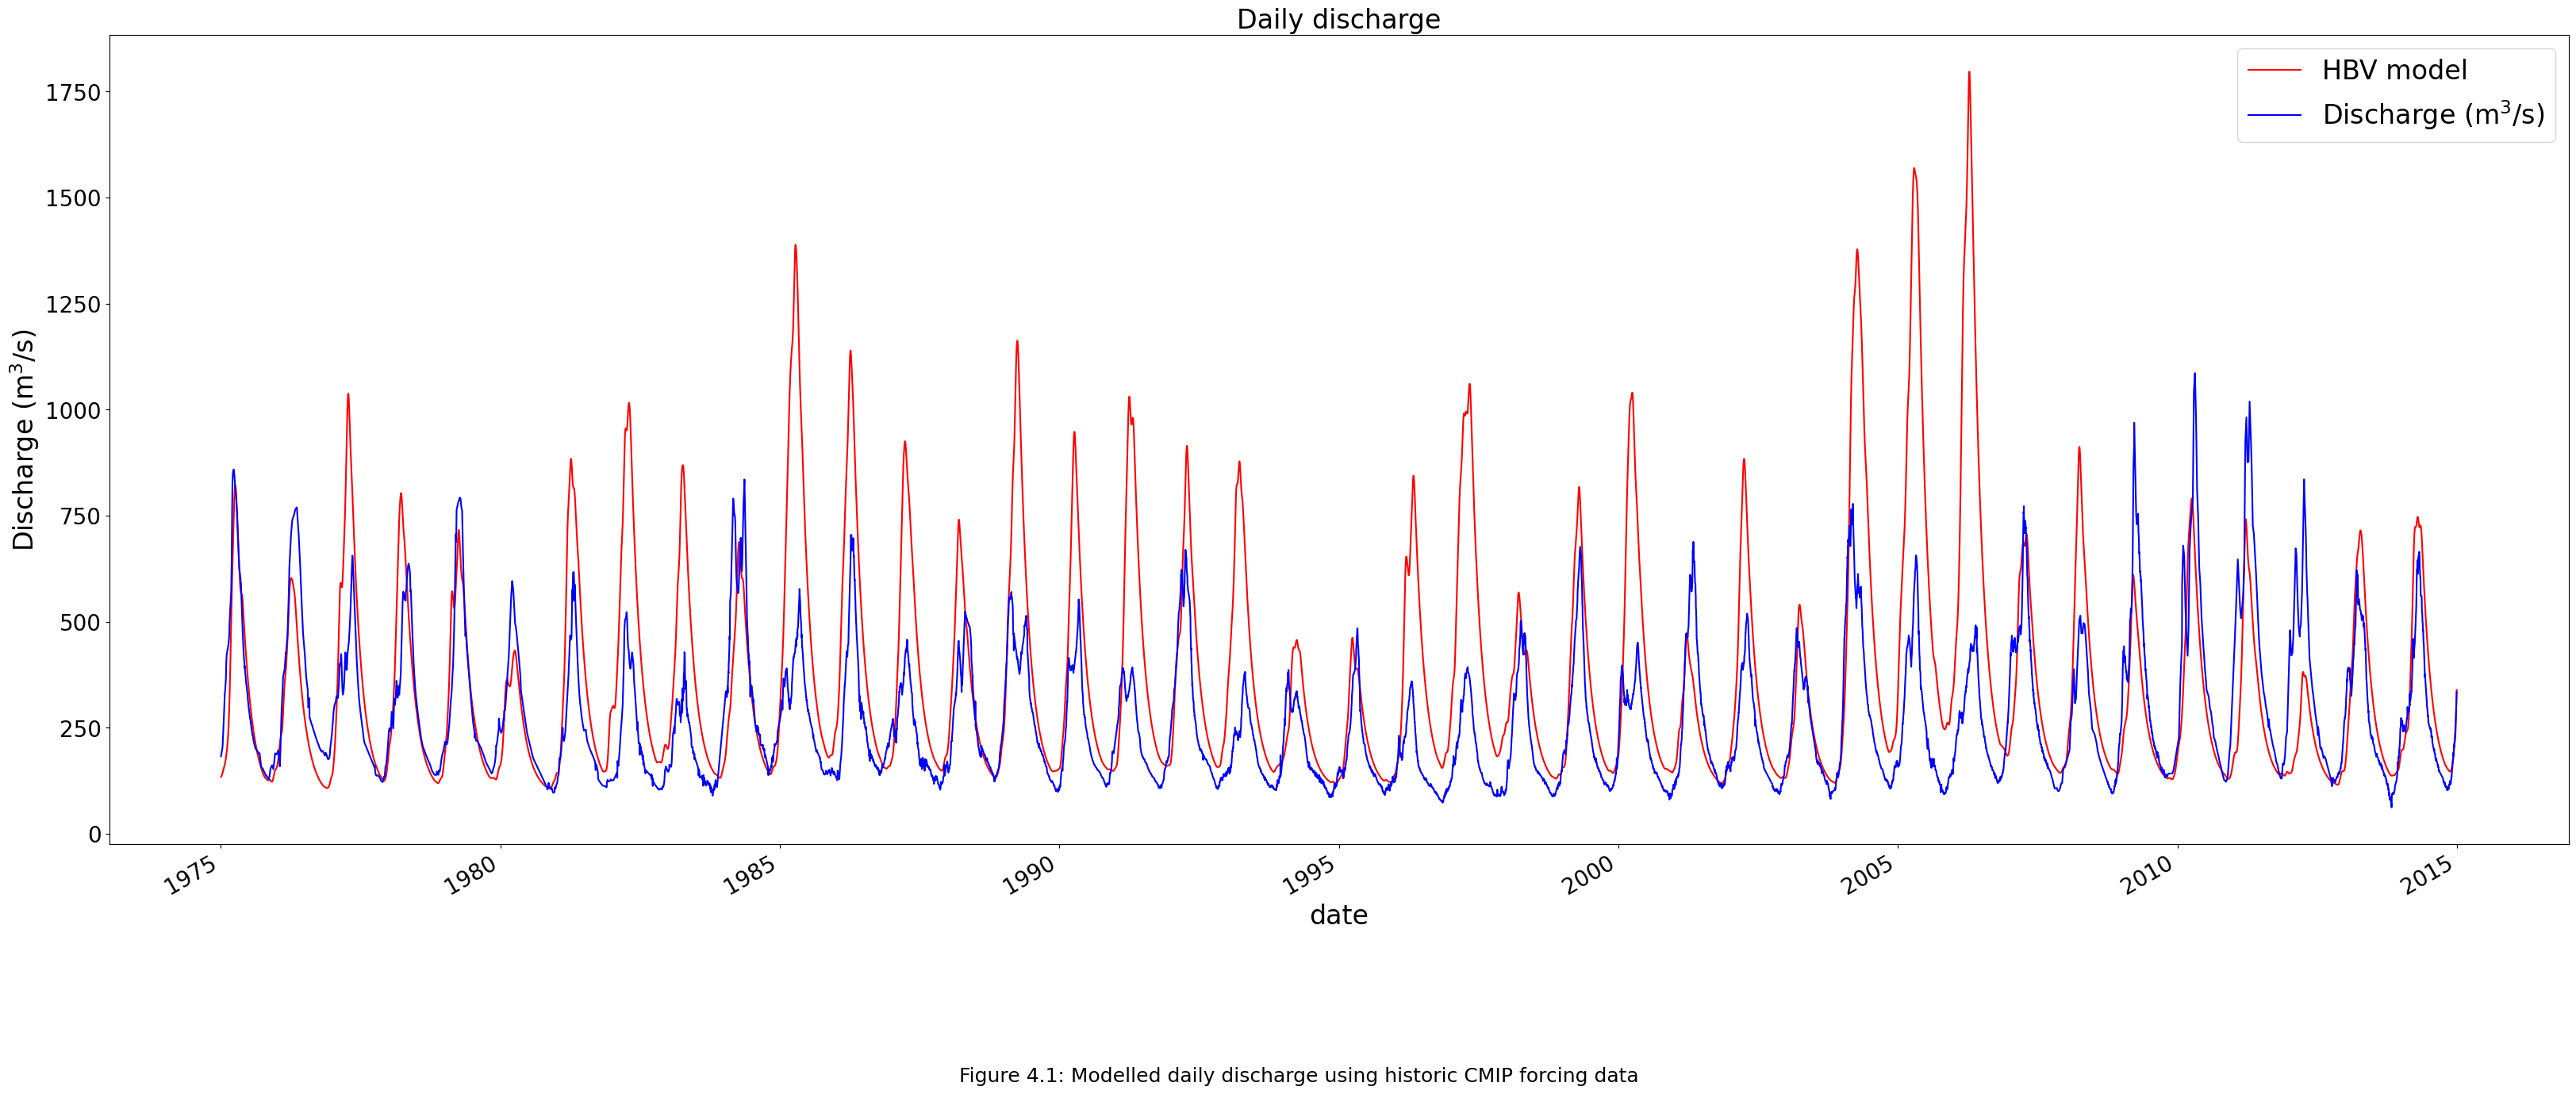

In [3]:
#Loading observed discharge data
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m$^3$/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2015, 2016, 2017, 2018, 2019, 2020, 2021])] #Aligning with historic CMIP period

#The model returns data in mm/day, while observed data is in m^3/s
Area_km2 = 173696.852
def mmday_to_m3s(mmday_data, area):
    return (mmday_data * area) / 86.4

#Calibrated parameters 
par_0 = [7.00392414e+00, 4.12282990e-01, 2.24893758e+03, 2.73819672e+00,
       1.84946158e-01, 2.24829623e+01, 1.49246751e-02, 6.55485347e-04,
       3.72295856e-01]

#Storages       Si,  Su,  Sf, Ss, Sp 
s_0 = np.array([0,  100,  0,  5,  0])

#Running the HBV model
model = ewatercycle.models.HBV(forcing=historical_CMIP_forcing)
config_file, _ = model.setup(parameters=par_0, initial_storage=s_0)
model.initialize(config_file)

Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

model.finalize()
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

#Converting data from mm/day to m^3/s
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")
Q_model_pd = Q_model_pd['1975'::] #Removing spin-up period

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m$^3$/s)", fontsize=24)
Q_model_pd.plot(ax=ax, color='red') 
data_daily.plot(ax=ax, color='blue')
plt.legend(fontsize=24)
plt.title('Daily discharge', fontsize=24)
fig.text(0.5, 0,"Figure 4.1: Modelled daily discharge using historic CMIP forcing data", ha="center", fontsize=18);

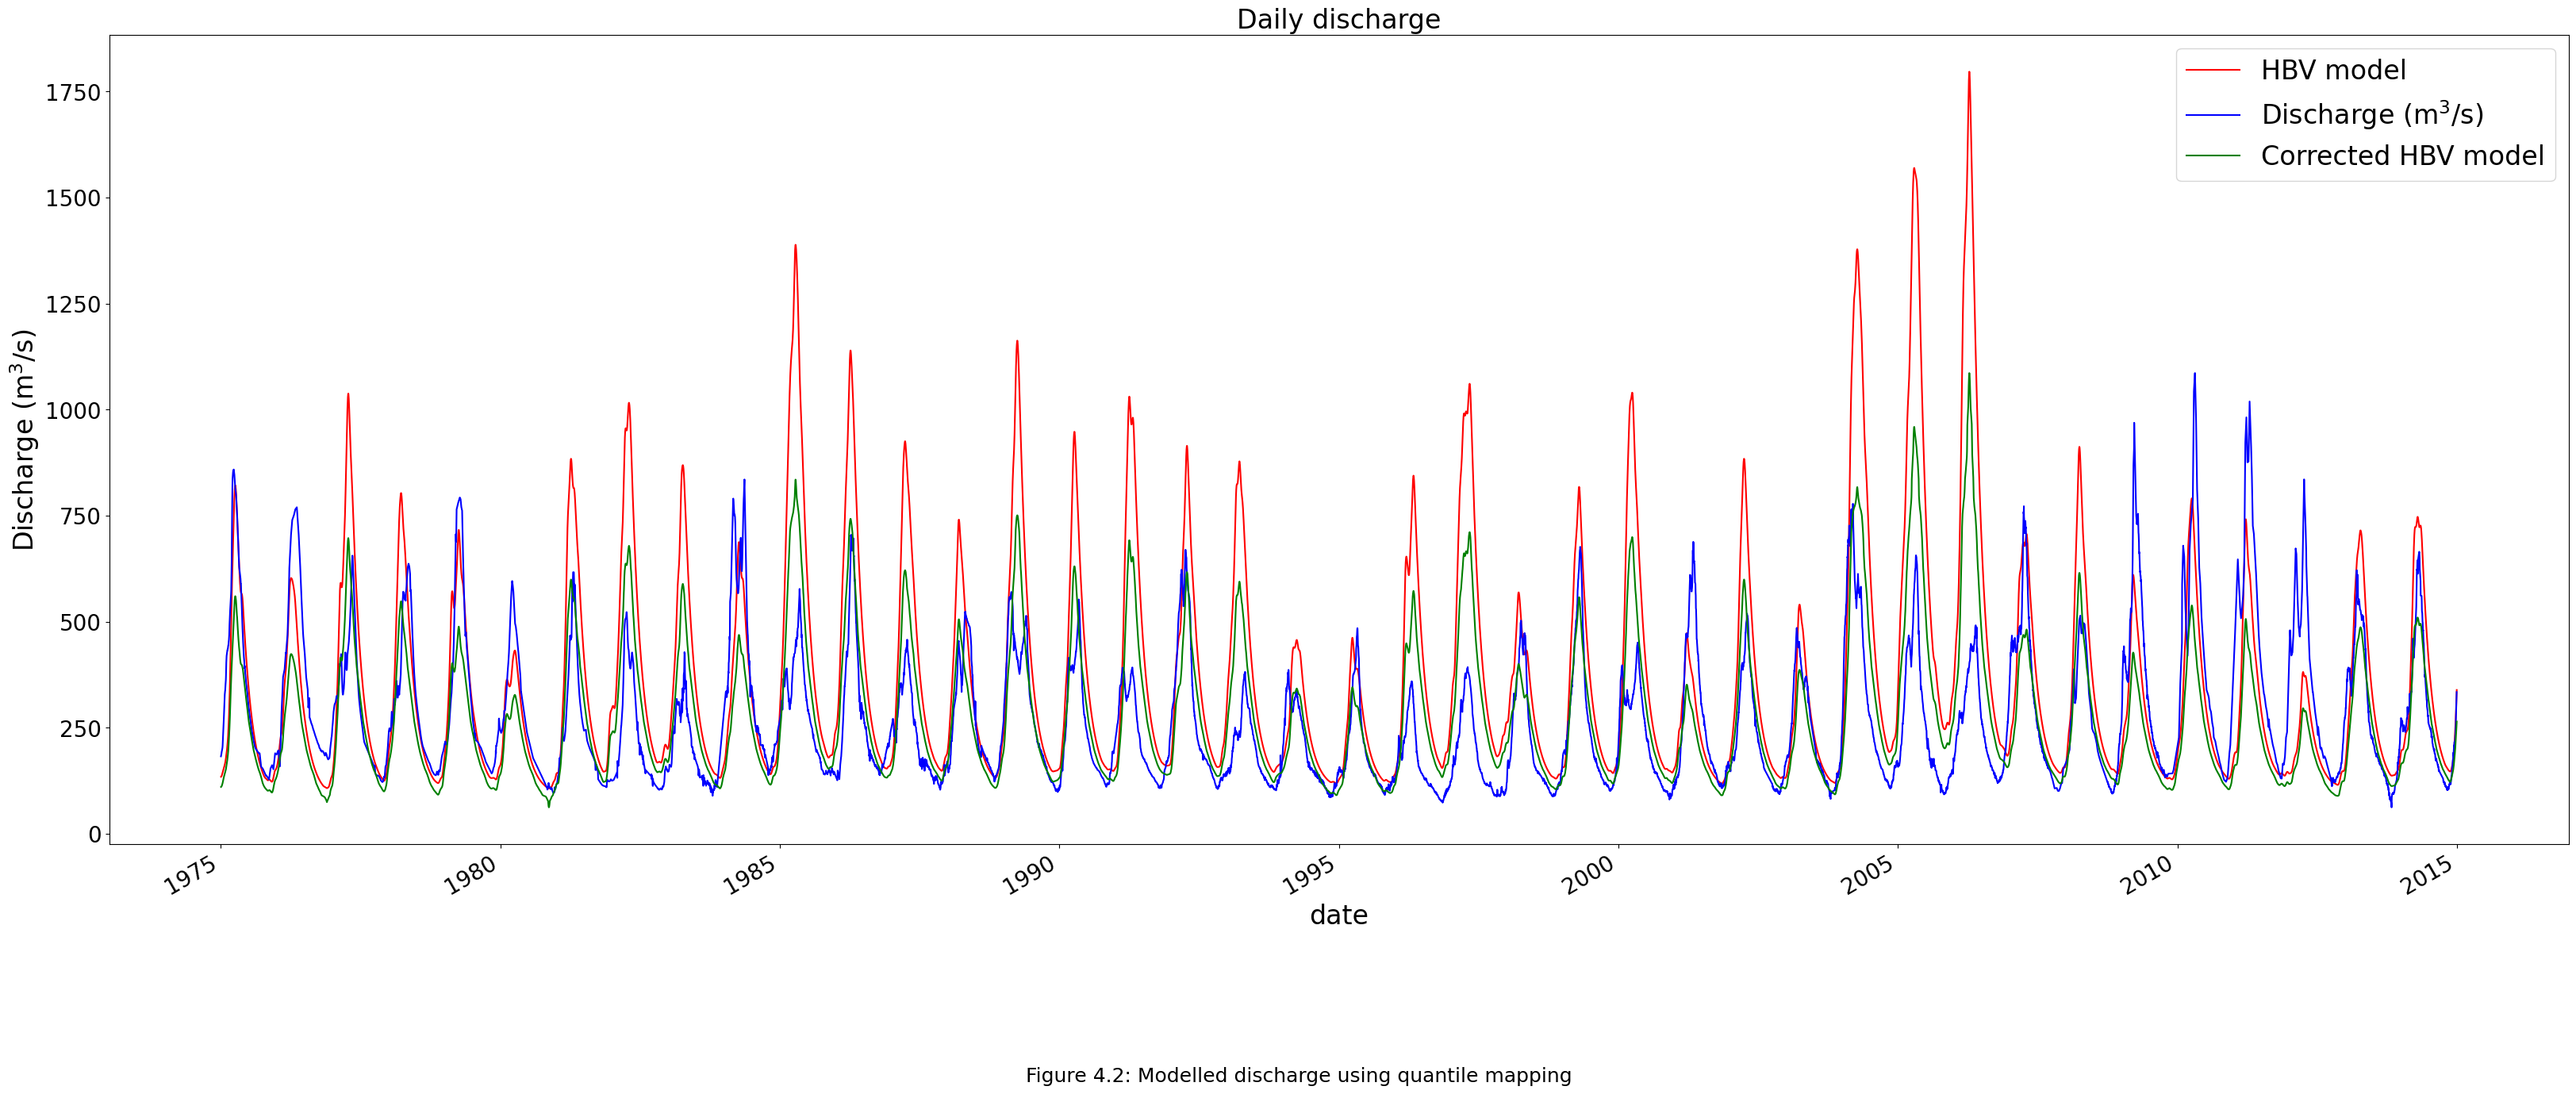

In [4]:
#Code of quantile mapping from Zoë Lucius (2025)
def quantile_mapping(observed, modelled, n):
    #Making a quantile grid 
    quantiles = np.linspace(0, 1, n)

    #Sorting data 
    observed_sorted = np.sort(observed)
    modelled_sorted = np.sort(modelled)

    #Assigning every data point to a quantile
    observed_interpolated = interp1d(np.linspace(0, 1, len(observed_sorted)), observed_sorted, bounds_error=False, fill_value="extrapolate")
    modelled_interpolated = interp1d(np.linspace(0, 1, len(modelled_sorted)), modelled_sorted, bounds_error=False, fill_value="extrapolate")

    #Aligning data points with quantile grid
    observed_on_quantiles = observed_interpolated(quantiles)
    modelled_on_quantiles = modelled_interpolated(quantiles)

    #Creating function to use on CMIP forcing data
    mapping_function = interp1d(modelled_on_quantiles, observed_on_quantiles, bounds_error=False, fill_value="extrapolate")

    return mapping_function

#Using quantile mapping
qm_func_daily = quantile_mapping(data_daily['Discharge (m$^3$/s)'], Q_model_pd, 1000)
CMIP_corrected_daily = qm_func_daily(Q_model_pd)

#Plotting results
fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m$^3$/s)", fontsize=24)
Q_model_pd.plot(ax=ax, color='red') 
data_daily.plot(ax=ax, color='blue')
plt.plot(Q_model_pd.index, CMIP_corrected_daily, label='Corrected HBV model', color='green')
plt.legend(fontsize=24)
plt.title('Daily discharge', fontsize=24)
fig.text(0.5, 0,"Figure 4.2: Modelled discharge using quantile mapping", ha="center", fontsize=18);

In figure 4.3, the yearly volumes of the observed, the HBV model historic using CMIP forcing data and bias corrected output is shown. For this report, return times of low yearly volumes that cause hydrological droughts in the Okavango Delta are more important than predicting the actual dry year. Although the exact years are inaccurate modelled using historic CMIP forcing data, the return times are similar when quantile mapping is used. The return times are shown in figure 4.4. The return times are calculated with the following formula (HydroInformatics, n.d.):

$$ \text{Return Interval} = \frac{n+1}{\mathrm{rank}} $$

$$ Where: $$
$$ \text{n} = \text{number of data points} $$
$$ \text{rank} = \text{rank of yearly volume} $$ 
The yearly volumes are first sorted from low to high. The lowest yearly volume is rank 1 and the highest volume is rank n. The code for generating the figures and calculating the return times is shown below.

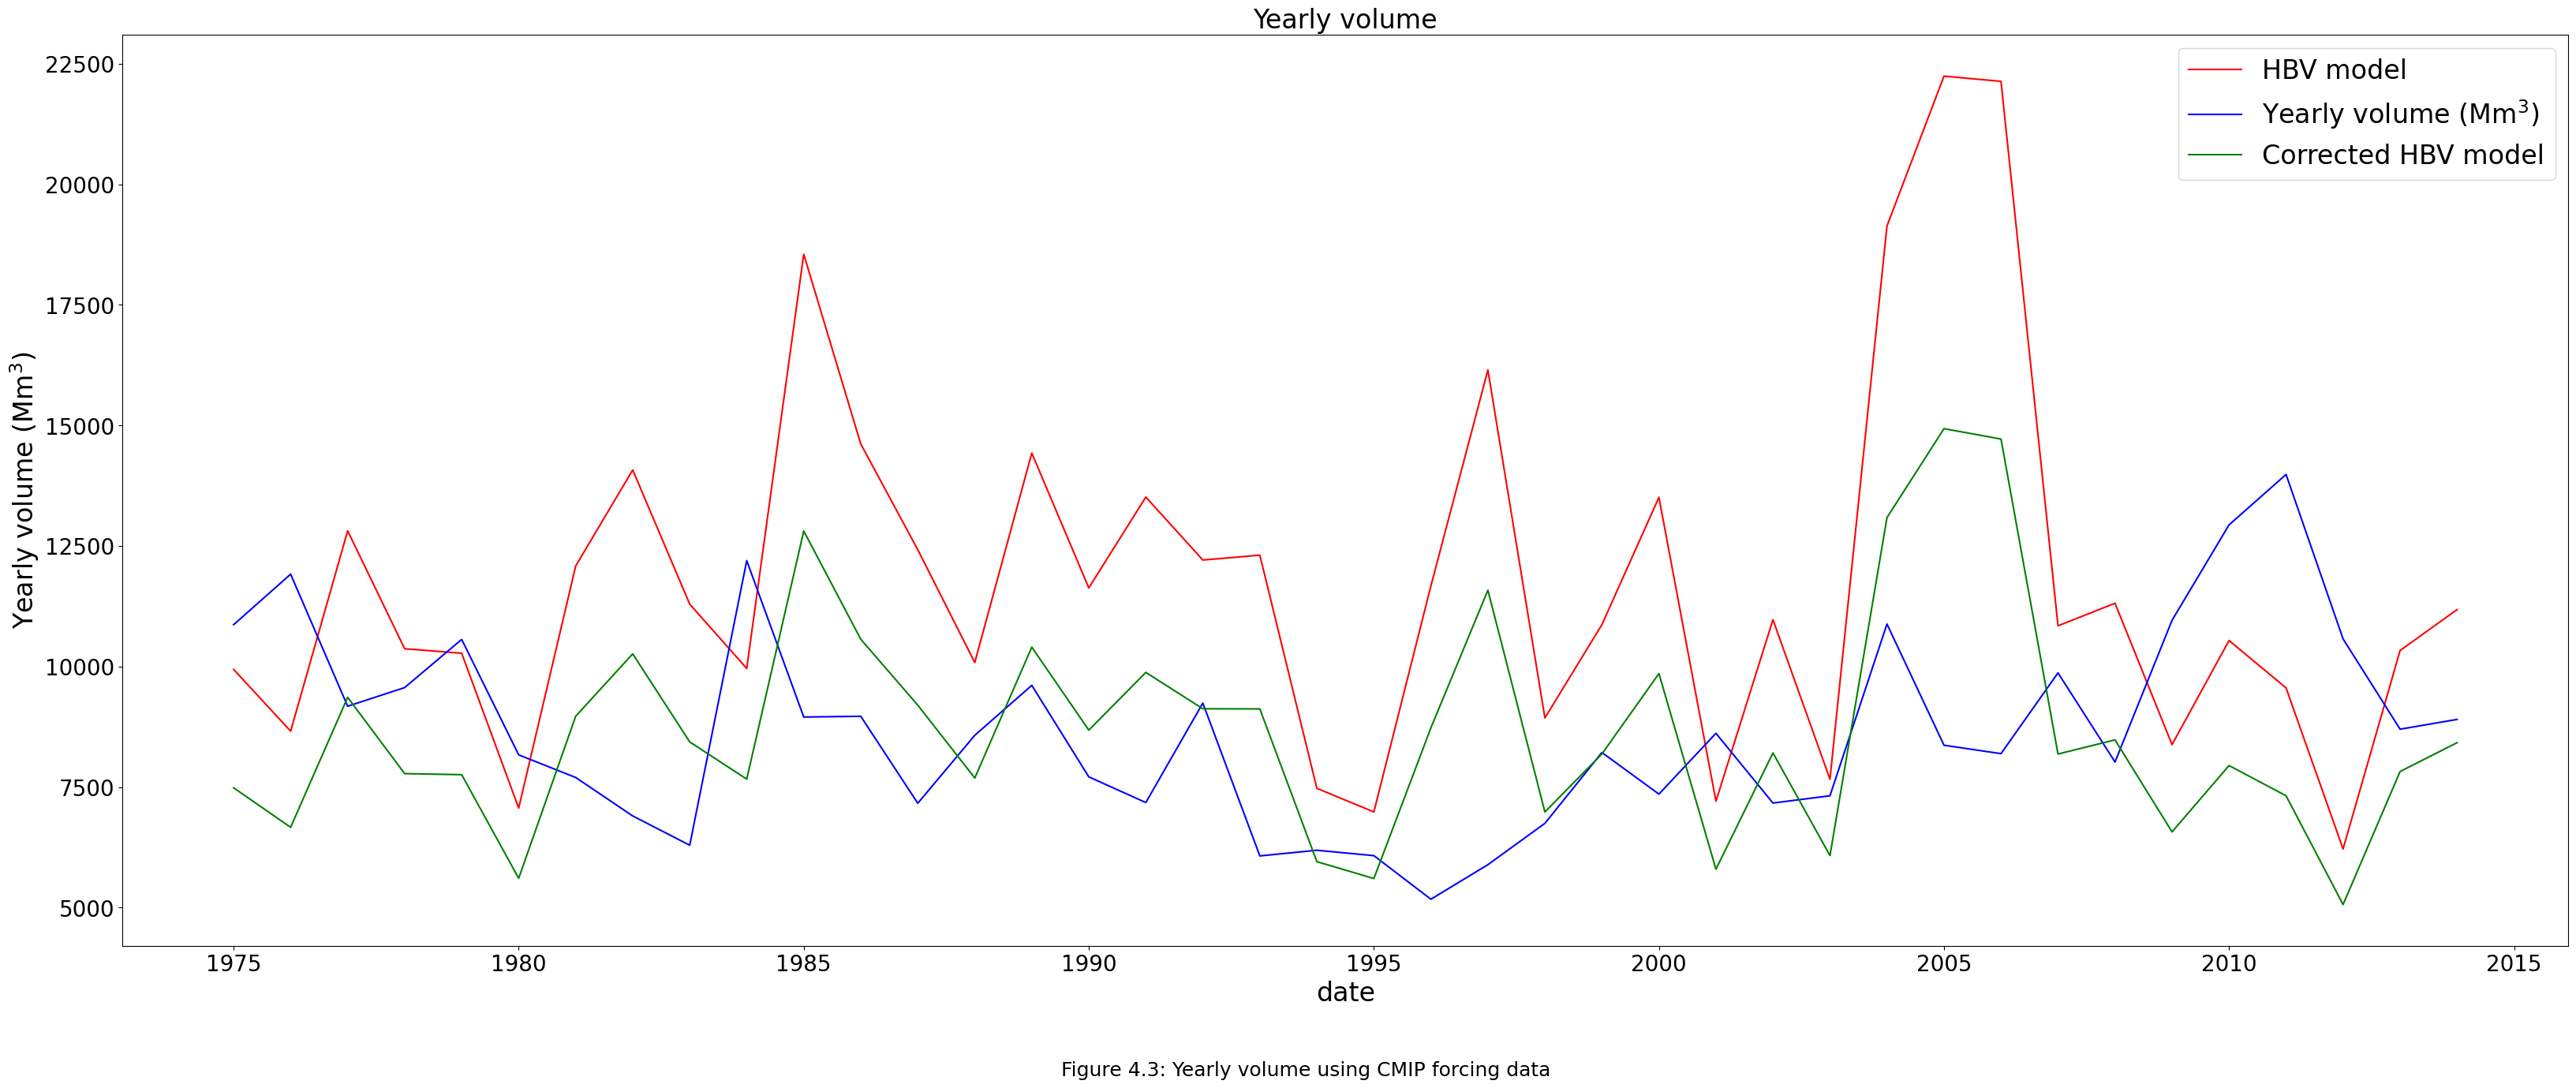

In [5]:
#Putting corrected output in a dataframe
CMIP_corrected = pd.DataFrame({'Corrected HBV model': CMIP_corrected_daily}, index=Q_model_pd.index)

#Converting data to yearly volumes
CMIP_yearly_corrected = (CMIP_corrected * 3600 * 24).resample('YE').sum() / 1e6
CMIP_yearly_corrected.index = CMIP_yearly_corrected.index.year

yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm$^3$)']
yearly_volume.index = yearly_volume.index.year

CMIP_yearly_volume = (Q_model_pd * 3600 * 24).resample('YE').sum() / 1e6
CMIP_yearly_volume.index = CMIP_yearly_volume.index.year

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm$^3$)", fontsize=24)
CMIP_yearly_volume.plot(ax=ax, color='red') #Removing the spin-up period from the plot
yearly_volume.plot(ax=ax, color='blue')
CMIP_yearly_corrected.plot(ax=ax, color='green')
plt.legend(fontsize=24)
plt.title('Yearly volume', fontsize=24)
fig.text(0.5, 0,"Figure 4.3: Yearly volume using CMIP forcing data", ha="center", fontsize=18);

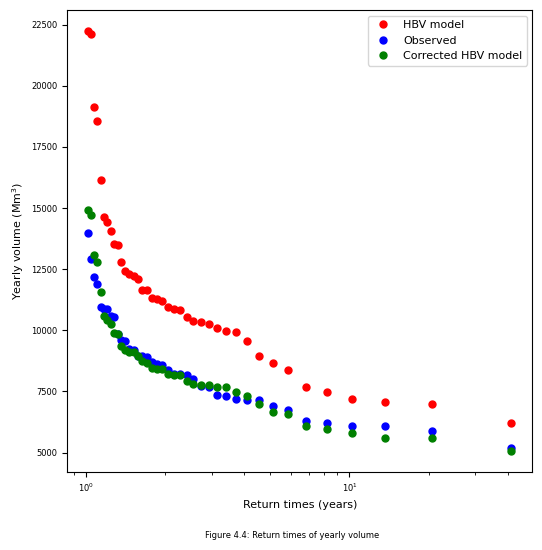

In [6]:
#Calculating return period
def return_periods(data):
    n = len(data)
    rank = np.arange(1, n + 1)
    return_period = (n + 1) / rank
    return return_period

#Using return period function
return_period = return_periods(CMIP_yearly_volume)

#Sorting data from low to high
CMIP_yearly_volume_sorted = np.sort(CMIP_yearly_volume)
CMIP_corrected_sorted = np.sort(CMIP_yearly_corrected['Corrected HBV model'])
Observed_sorted = np.sort(yearly_volume['Yearly volume (Mm$^3$)'])

#Plotting
fig, ax = plt.subplots(figsize=(6, 6))
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
ax.set_xlabel("Return times (years)", fontsize=8)
ax.set_ylabel("Yearly volume (Mm$^3$)", fontsize=8)
plt.xscale('log')

plt.plot(return_period, CMIP_yearly_volume_sorted, marker='o', linestyle='None', ms=5, label='HBV model', color='red')
plt.plot(return_period, Observed_sorted, marker='o', linestyle='None', ms=5, label='Observed', color='blue')
plt.plot(return_period, CMIP_corrected_sorted, marker='o', linestyle='None', ms=5, label='Corrected HBV model', color='green')
plt.legend(fontsize=8)
fig.text(0.5, 0,"Figure 4.4: Return times of yearly volume", ha="center", fontsize=6);

## 4.3 Projecting future discharge
For the projection of the future discharge pattern of the Okavango River, the same bias correction as the historic HBV model using CMIP forcing data is used. In figures 4.5 and 4.6, the discharge and yearly volume is shown for the different climate scenarios. In chapter 5, the results of the future projection will be analyzed. How to model future discharge is shown in the code below. The code for generating the future forcing data and setting up the HBV model for different scenarios is given in general form. The projected daily discharge and yearly volumes were coded in a seperate notebook and the results were saved to a csv file. These files are used to generate the figures.

In [7]:
#Generating future forcing data 
#Forcing data for different scenarios can be generated by changing ssp126/SSP126 to the desired scenario

#future_experiment_start_date = "2027-01-01T00:00:00Z"
#future_experiment_end_date = "2099-12-31T00:00:00Z"
#forcing_path_CMIP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/CMIP" / "CMIP_future"
#forcing_path_CMIP.mkdir(exist_ok=True)

#cmip_dataset =  {
#   'project': 'CMIP6',
#   'activity': 'ScenarioMIP',
#   'exp': 'ssp126',
#   'mip': 'day',
#   'dataset': 'MPI-ESM1-2-HR',
#   'ensemble': 'r1i1p1f1',
#   'institute': 'DKRZ',
#   'grid': 'gn'
#}

#CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].generate(
#   dataset=cmip_dataset,
#   start_time=future_experiment_start_date,
#   end_time=future_experiment_end_date,
#   shape=shapefile_path,
#   directory=forcing_path_CMIP / "SSP126",
#)

In [8]:
#Setting up HBV model for SSP1-2.6. By changing forcing data, another scenario can be modelled

#parameters = [7.00392414e+00, 4.12282990e-01, 2.24893758e+03, 2.73819672e+00,
#       1.84946158e-01, 2.24829623e+01, 1.49246751e-02, 6.55485347e-04,
#       3.72295856e-01]
#s_0 = np.array([0,  100,  0,  5,  0])

#model = ewatercycle.models.HBV(forcing=SSP126_CMIP_forcing)
#config_file, _ = model.setup(parameters=parameters, initial_storage=s_0)
#model.initialize(config_file)

#Q_m = []
#time = []
#while model.time < model.end_time:
#    model.update()
#    Q_m.append(model.get_value("Q")[0])
#    time.append(pd.Timestamp(model.time_as_datetime))
#model.finalize()

#model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)
#Q_model = mmday_to_m3s(model_output.values, Area_km2)
#Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")
#Q_model_pd = Q_model_pd[Q_model_pd.index >= '2030-01-01']
#Q_model_pd = Q_model_pd.sort_index()

#qm_func_daily = quantile_mapping(data_daily['Discharge (m^3/s)'], Q_model_pd, 1000)
#CMIP_corrected_daily = qm_func_daily(Q_model_pd)
#CMIP_corrected_daily = pd.DataFrame({'Corrected': CMIP_corrected_daily}, index=Q_model_pd.index)

#Q_model_pd_volume = (CMIP_corrected_daily * 3600 * 24).resample('YE').sum() / 1e6

#Saving data files
#CMIP_corrected_daily.to_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/SSP126_daily.csv")
#Q_model_pd_volume.to_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/SSP126_yearly.csv")

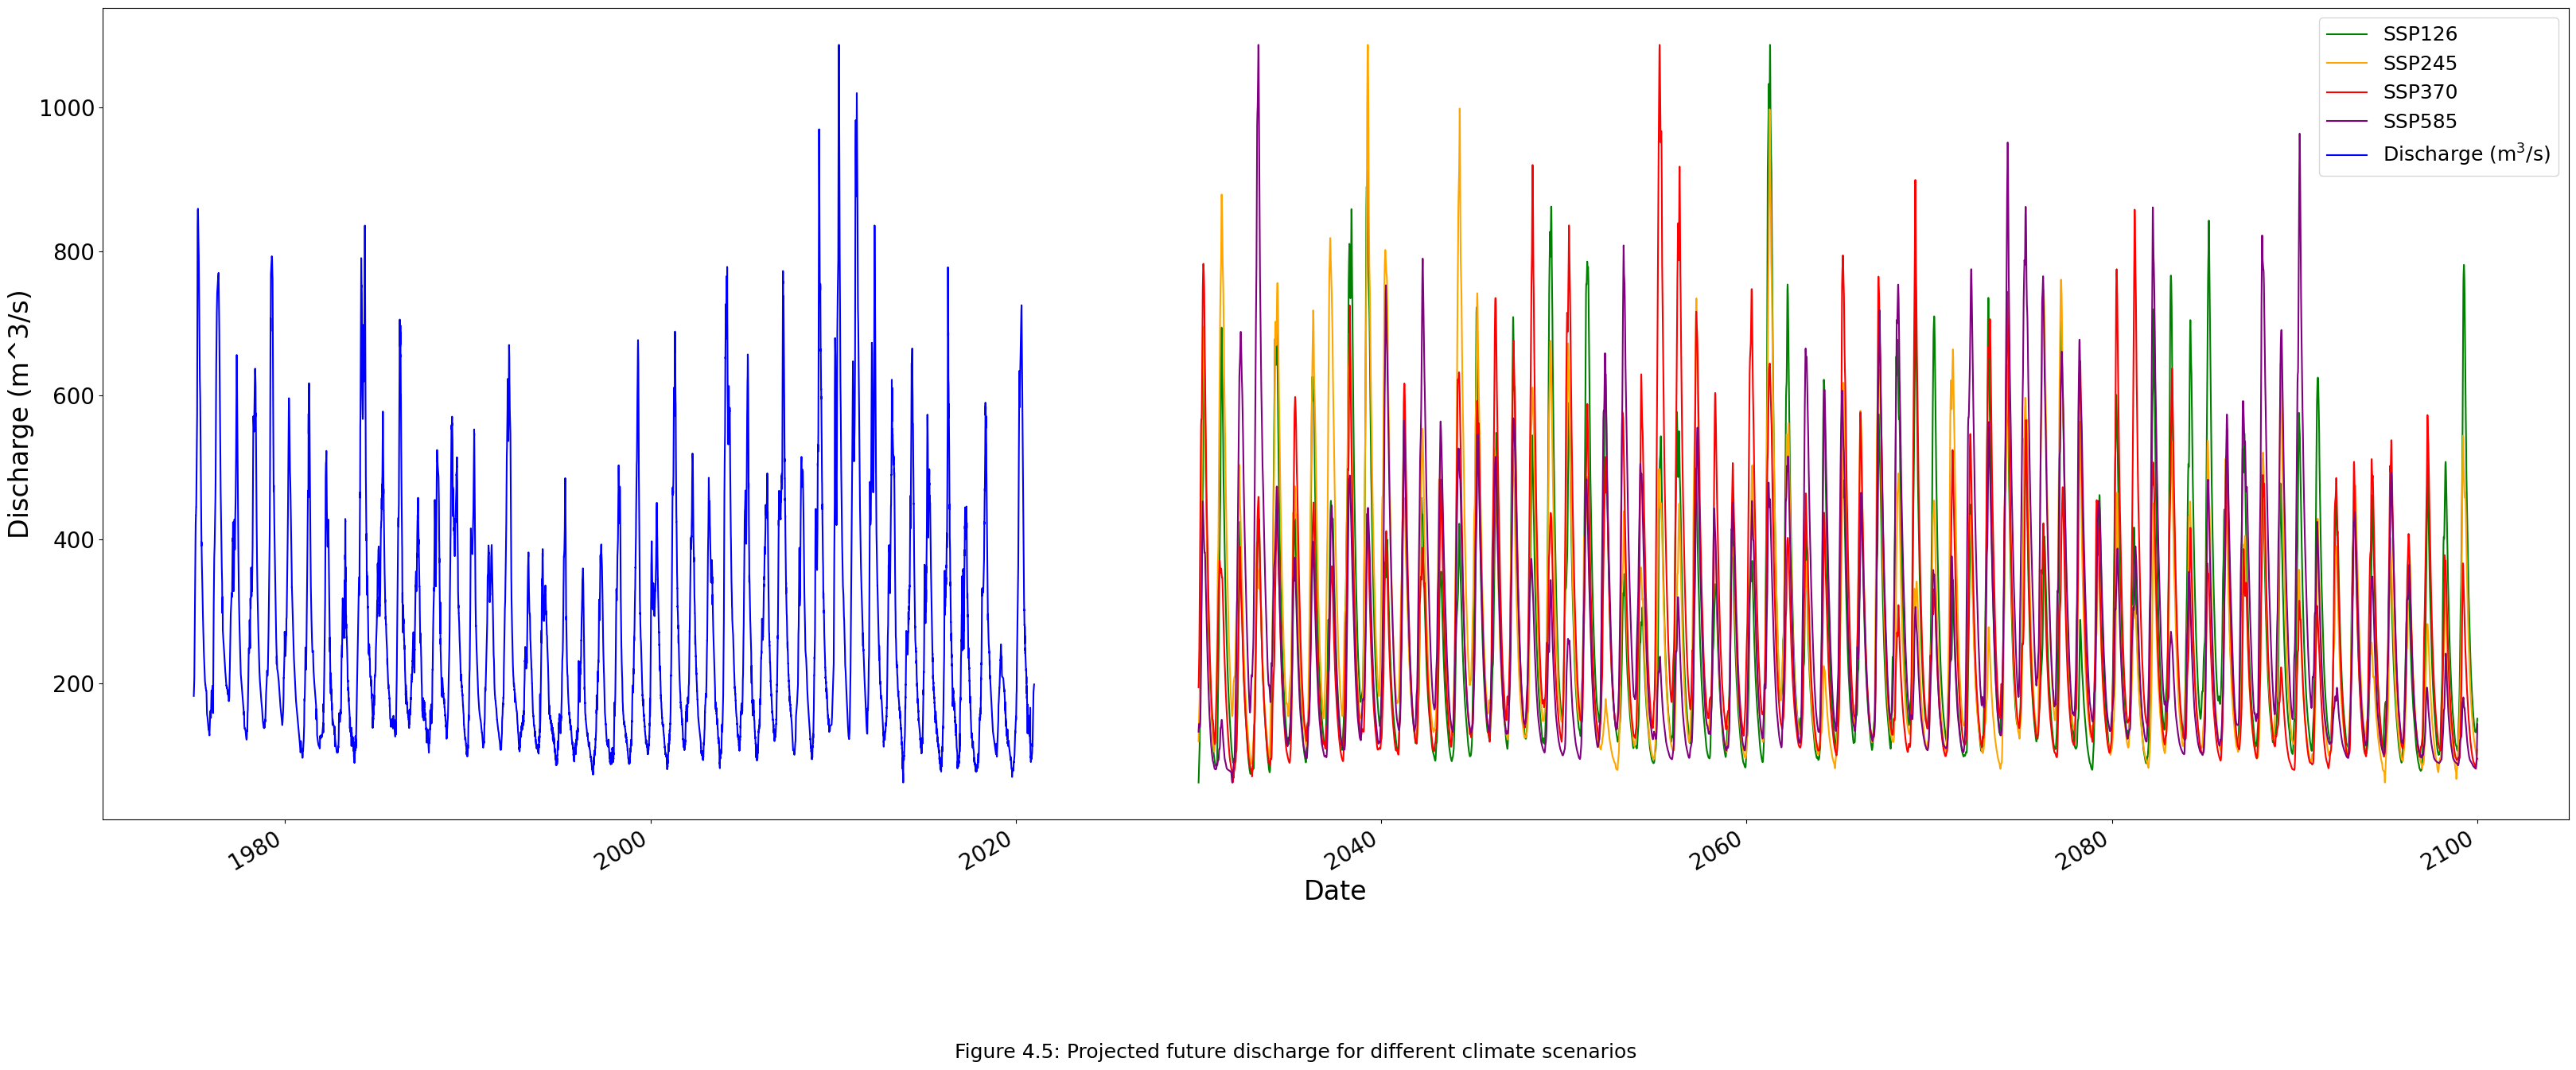

In [9]:
#Loading observed daily discharge data for whole timeperiod
data = pd.read_csv(Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data/mohembo_daily_water_discharge_data.csv", 
                   index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m$^3$/s)']
data_daily = data_daily[~data_daily.index.year.isin([1974, 2021])]

#Path to SSP scenario results
path_SSP = Path.home() / "BEP-beau/book/thesis_projects/BSc/2026_Q4_BeauBuijtenhuijs_CEG/Data"

#Loading daily discharge data for the different scenarios
SSP126_daily = pd.read_csv(path_SSP / 'SSP126_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP126'], header=0)
SSP245_daily = pd.read_csv(path_SSP / 'SSP245_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP245'], header=0)
SSP370_daily = pd.read_csv(path_SSP / 'SSP370_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP370'], header=0)
SSP585_daily = pd.read_csv(path_SSP / 'SSP585_daily.csv', index_col=0, parse_dates=True, names=['Date', 'SSP585'], header=0)

#Plotting
fig, ax = plt.subplots(figsize=(40, 15))
SSP126_daily.plot(ax=ax, color='green')
SSP245_daily.plot(ax=ax, color='orange')
SSP370_daily.plot(ax=ax, color='red')
SSP585_daily.plot(ax=ax, color='purple')
data_daily.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
plt.xlim('1970', '2105')
plt.legend(fontsize=18)
fig.text(0.5, 0,"Figure 4.5: Projected future discharge for different climate scenarios", ha="center", fontsize=18);

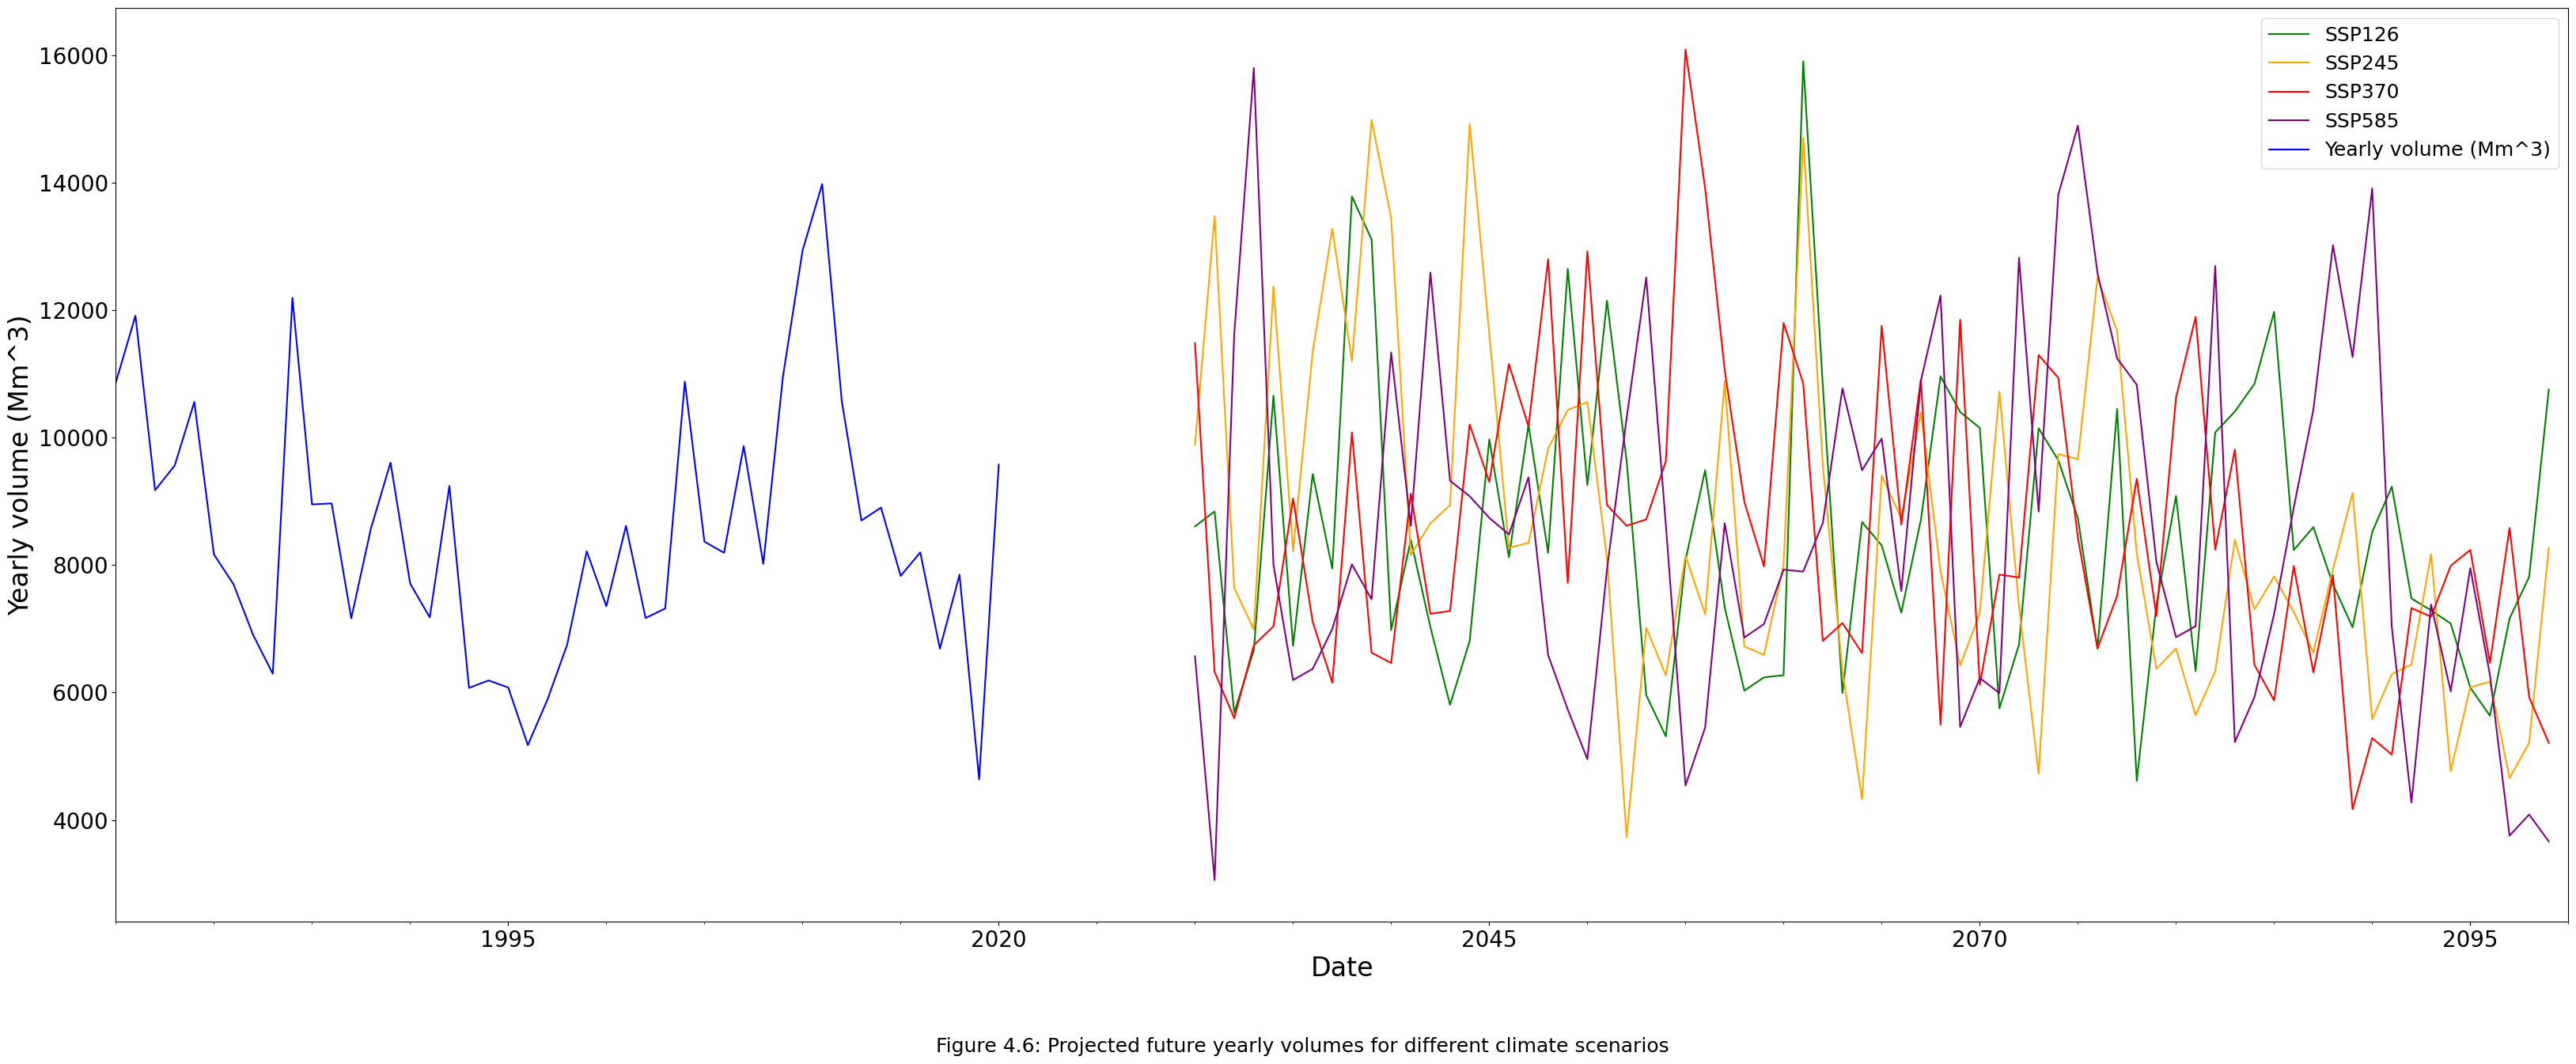

In [10]:
#Loading yearly volume data for the different scenarios
SSP126_yearly = pd.read_csv(path_SSP / 'SSP126_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP126'], header=0)
SSP245_yearly = pd.read_csv(path_SSP / 'SSP245_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP245'], header=0)
SSP370_yearly = pd.read_csv(path_SSP / 'SSP370_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP370'], header=0)
SSP585_yearly = pd.read_csv(path_SSP / 'SSP585_yearly.csv', index_col=0, parse_dates=True, names=['Date', 'SSP585'], header=0)

yearly_volume = (data_daily * 3600 * 24).resample('YE').sum() / 1e6
yearly_volume.columns = ['Yearly volume (Mm^3)']

#Plotting
fig, ax = plt.subplots(figsize=(40, 15))
SSP126_yearly.plot(ax=ax, color='green')
SSP245_yearly.plot(ax=ax, color='orange')
SSP370_yearly.plot(ax=ax, color='red')
SSP585_yearly.plot(ax=ax, color='purple')
yearly_volume.plot(ax=ax, color='blue')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Yearly volume (Mm^3)", fontsize=24)
plt.xlim('1975', '2100')
plt.legend(fontsize=18)
fig.text(0.5, 0,"Figure 4.6: Projected future yearly volumes for different climate scenarios", ha="center", fontsize=18);